# Visualization (Operator-wise IQ by Dataset) — RQ1

This notebook generates an operator-wise mutant level IQ plot **split by dataset** (CleanML, DeepFD, DeepLocalize).

**Goal:** for each operator, show **three distributions** (one per dataset) of **mutant-level IQ** values.

- **Input:** `results/quality/quality_<bug>_pre_training.csv`
- **Output:** `figures/operator_iq_boxplot_by_dataset.pdf`

## What is plotted?
For each operator and dataset, we pool **all mutants** across all subject systems in that dataset and plot the distribution of their **IQ** values.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np 

In [2]:
# -----------------------------
# Operator order + display names (Table 1)
# Left = code identifier (as in quality CSV), Right = paper ID
# -----------------------------
OPERATOR_ORDER = [
    ("change_label", "TCL"),
    ("delete_training_data", "TRD"),
    ("unbalance_train_data", "TUD"),
    ("add_noise", "TAN"),
    ("make_output_classes_overlap", "TCO"),
    ("change_batch_size", "HBS"),
    ("change_learning_rate", "HLR"),
    ("change_epochs", "HNE"),
    ("disable_batching", "HDB"),
    ("change_activation_function", "ACH"),
    ("remove_activation_function", "ARM"),
    ("add_activation_function", "AAL"),
    ("add_weights_regularisation", "RAW"),
    ("change_weights_regularisation", "RCW"),
    ("remove_weights_regularisation", "RRW"),
    ("change_dropout_rate", "RCD"),
    ("change_earlystopping_patience", "RCP"),
    ("change_weights_initialisation", "WCI"),
    ("add_bias", "WAB"),
    ("remove_bias", "WRB"),
    ("change_loss_function", "LCH"),
    ("change_optimisation_function", "OCH"),
    ("change_gradient_clip", "OCG"),
    ("remove_validation_set", "VRM"),
]

OPERATOR_IDS = [op for op, _ in OPERATOR_ORDER]
OPERATOR_LABELS = {op: label for op, label in OPERATOR_ORDER}


In [3]:
# -----------------------------
# Paths (edit if needed)
# -----------------------------
RESULTS_DIR = Path("results")
QUALITY_DIR = RESULTS_DIR / "quality"
FIGURES_DIR = Path("figures")  # same level as results/

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("QUALITY_DIR:", QUALITY_DIR.resolve())
print("FIGURES_DIR:", FIGURES_DIR.resolve())

QUALITY_DIR: D:\Experiments\dl-mutant-quality\results\quality
FIGURES_DIR: D:\Experiments\dl-mutant-quality\figures


In [4]:
# -----------------------------
# Collect quality CSVs
# -----------------------------
csv_files = sorted(QUALITY_DIR.glob("quality_*_pre_training.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No quality CSVs found under {QUALITY_DIR}. "
        "Expected files like: quality_<bug>_pre_training.csv"
    )

print(f"Found {len(csv_files)} quality CSV files.")

Found 86 quality CSV files.


In [5]:
# -----------------------------
# Load all mutant-level IQ rows (selection datasets only)
# -----------------------------
def dataset_of_bug(bug_id: str) -> str:
    if bug_id.startswith("cleanml"):
        return "CleanML"
    if bug_id.startswith("deepfd"):
        return "DeepFD"
    if bug_id.startswith("deeplocalize"):
        return "DeepLocalize"
    return "Other"

rows = []
skipped_files = 0

for f in csv_files:
    df = pd.read_csv(f)

    required = {"bug_id", "operator", "IQ"}
    if not required.issubset(df.columns):
        skipped_files += 1
        continue

    bug_id = str(df["bug_id"].iloc[0])
    ds = dataset_of_bug(bug_id)
    if ds == "Other":
        continue  # exclude defect4ml

    tmp = df[["operator", "IQ"]].dropna().copy()
    tmp["IQ"] = tmp["IQ"].astype(float)
    tmp["dataset"] = ds
    rows.append(tmp)

op_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

print("Skipped files (missing columns):", skipped_files)
print("Loaded mutant-level rows:", len(op_df))
print("Operators:", op_df["operator"].nunique())
print("Mutants per dataset:")
print(op_df.groupby("dataset")["IQ"].count())

Skipped files (missing columns): 0
Loaded mutant-level rows: 9612
Operators: 19
Mutants per dataset:
dataset
CleanML         2748
DeepFD          3867
DeepLocalize    2997
Name: IQ, dtype: int64


In [6]:
# -----------------------------
# Sanity checks: mismatch between Table 1 operator IDs and the data
# -----------------------------
ops_in_data = set(op_df["operator"].unique())
ops_in_table = set(OPERATOR_IDS)

print("Operators in data but NOT in OPERATOR_ORDER:")
print(sorted(ops_in_data - ops_in_table))

print("\nOperators in OPERATOR_ORDER but missing in data:")
print(sorted(ops_in_table - ops_in_data))


Operators in data but NOT in OPERATOR_ORDER:
[]

Operators in OPERATOR_ORDER but missing in data:
['add_bias', 'change_earlystopping_patience', 'change_gradient_clip', 'change_weights_regularisation', 'remove_weights_regularisation']


In [7]:
# -----------------------------
# Operator order (by overall median IQ, across all datasets)
# -----------------------------
op_order = [op for op in OPERATOR_IDS if op in set(op_df["operator"].unique())]
datasets = ["CleanML", "DeepFD", "DeepLocalize"]

print("Operator order (top 10):", op_order[:10])

Operator order (top 10): ['change_label', 'delete_training_data', 'unbalance_train_data', 'add_noise', 'make_output_classes_overlap', 'change_batch_size', 'change_learning_rate', 'change_epochs', 'disable_batching', 'change_activation_function']


In [8]:
# -----------------------------
# Colors: use matplotlib default cycle (no hard-coded specific colors)
# -----------------------------
cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ds_to_color = {
    "CleanML": cycle[0] if len(cycle) > 0 else None,
    "DeepFD": cycle[1] if len(cycle) > 1 else None,
    "DeepLocalize": cycle[2] if len(cycle) > 2 else None,
}

In [9]:
# -----------------------------
# Build grouped boxplot positions (3 boxes per operator)
# -----------------------------
data = []
positions = []
colors = []
tick_positions = []
tick_labels = []

group_gap = 0.5   # gap between operator groups
within_gap = 0.30 # spacing within group
box_width = 0.20

pos = 1.0
for op in op_order:
    # center tick for the operator group
    group_positions = []
    for k, ds in enumerate(datasets):
        vals = op_df.loc[(op_df["operator"] == op) & (op_df["dataset"] == ds), "IQ"].values
        data.append(vals)
        p = pos + k * within_gap
        positions.append(p)
        group_positions.append(p)
        colors.append(ds_to_color[ds])
    tick_positions.append(sum(group_positions) / len(group_positions))
    tick_labels.append(OPERATOR_LABELS.get(op, op))
    pos = pos + 3 * within_gap + group_gap

print("Prepared boxes:", len(data))

Prepared boxes: 57


Saved: D:\Experiments\dl-mutant-quality\figures\operator_iq_boxplot_by_dataset.pdf


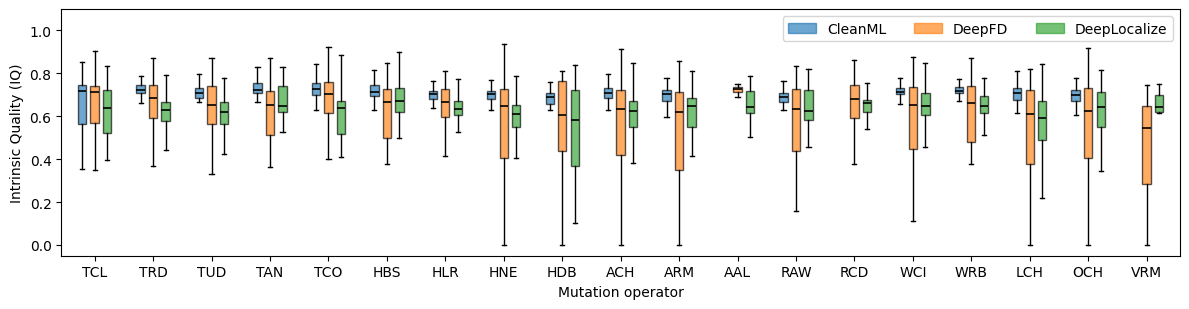

In [10]:
# -----------------------------
# Plot: grouped operator × dataset boxplot
# -----------------------------
plt.figure(figsize=(max(12, len(op_order) * 0.6), 3.2))

bp = plt.boxplot(
    data,
    positions=positions,
    widths=box_width,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0),
)

for patch, c in zip(bp["boxes"], colors):
    if c is not None:
        patch.set_facecolor(c)
        patch.set_alpha(0.65)

plt.xticks(tick_positions, tick_labels, rotation=0, ha="center")
plt.ylabel("Intrinsic Quality (IQ)")
plt.xlabel("Mutation operator")

# ---- Y-axis: ticks 0..1 step 0.2 + ±5% padding ----
ax = plt.gca()
ax.set_yticks(np.arange(0, 1.01, 0.2))  # 0, 0.2, ..., 1.0
pad = 0.1  # 5% of the [0,1] range
ax.set_ylim(-pad + 0.05, 1 + pad)              # (-0.05, 1.1)

# Legend
handles = [
    mpatches.Patch(color=ds_to_color["CleanML"], alpha=0.65, label="CleanML"),
    mpatches.Patch(color=ds_to_color["DeepFD"], alpha=0.65, label="DeepFD"),
    mpatches.Patch(color=ds_to_color["DeepLocalize"], alpha=0.65, label="DeepLocalize"),
]

plt.legend(handles=handles, loc="upper right", ncol=3, frameon=True)

plt.tight_layout()

out_pdf = FIGURES_DIR / "operator_iq_boxplot_by_dataset.pdf"
plt.savefig(out_pdf, format="pdf")
print("Saved:", out_pdf.resolve())

plt.show()

## Notes
- Each box contains **all mutants** for a given (operator, dataset), pooled across all bugs in that dataset.
- If an operator is absent in a dataset, that box will be empty!

# Visualization (Operator-wise EQ by Dataset) — RQ2

This notebook generates an operator-wise EQ plot **split by dataset** (CleanML, DeepFD, DeepLocalize).

**Goal:** for each operator, show **three distributions** (one per dataset) of **mutant-level EQ** values.

- **Input:** `results/quality/quality_<bug>_pre_training.csv`
- **Output:** `figures/operator_iq_boxplot_by_dataset.pdf`

## What is plotted?
For each operator and dataset, we pool **all mutants** across all bugs in that dataset and plot the distribution of their **EQ** values.

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [12]:
# -----------------------------
# Operator order + display names (Table 1)
# Left = code identifier (as in quality CSV), Right = paper ID
# -----------------------------
OPERATOR_ORDER = [
    ("change_label", "TCL"),
    ("delete_training_data", "TRD"),
    ("unbalance_train_data", "TUD"),
    ("add_noise", "TAN"),
    ("make_output_classes_overlap", "TCO"),
    ("change_batch_size", "HBS"),
    ("change_learning_rate", "HLR"),
    ("change_epochs", "HNE"),
    ("disable_batching", "HDB"),
    ("change_activation_function", "ACH"),
    ("remove_activation_function", "ARM"),
    ("add_activation_function", "AAL"),
    ("add_weights_regularisation", "RAW"),
    ("change_weights_regularisation", "RCW"),
    ("remove_weights_regularisation", "RRW"),
    ("change_dropout_rate", "RCD"),
    ("change_earlystopping_patience", "RCP"),
    ("change_weights_initialisation", "WCI"),
    ("add_bias", "WAB"),
    ("remove_bias", "WRB"),
    ("change_loss_function", "LCH"),
    ("change_optimisation_function", "OCH"),
    ("change_gradient_clip", "OCG"),
    ("remove_validation_set", "VRM"),
]

OPERATOR_IDS = [op for op, _ in OPERATOR_ORDER]
OPERATOR_LABELS = {op: label for op, label in OPERATOR_ORDER}

In [13]:
# -----------------------------
# Paths (edit if needed)
# -----------------------------
RESULTS_DIR = Path("results")
QUALITY_DIR = RESULTS_DIR / "quality"
FIGURES_DIR = Path("figures")  # same level as results/

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("QUALITY_DIR:", QUALITY_DIR.resolve())
print("FIGURES_DIR:", FIGURES_DIR.resolve())

QUALITY_DIR: D:\Experiments\dl-mutant-quality\results\quality
FIGURES_DIR: D:\Experiments\dl-mutant-quality\figures


In [14]:
# -----------------------------
# Collect quality CSVs
# -----------------------------
csv_files = sorted(QUALITY_DIR.glob("quality_*_pre_training.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No quality CSVs found under {QUALITY_DIR}. "
        "Expected files like: quality_<bug>_pre_training.csv"
    )

print(f"Found {len(csv_files)} quality CSV files.")

Found 86 quality CSV files.


In [15]:
# -----------------------------
# Load all mutant-level IQ rows (selection datasets only)
# -----------------------------
def dataset_of_bug(bug_id: str) -> str:
    if bug_id.startswith("cleanml"):
        return "CleanML"
    if bug_id.startswith("deepfd"):
        return "DeepFD"
    if bug_id.startswith("deeplocalize"):
        return "DeepLocalize"
    return "Other"

rows = []
skipped_files = 0

for f in csv_files:
    df = pd.read_csv(f)

    required = {"bug_id", "operator", "EQ"}
    if not required.issubset(df.columns):
        skipped_files += 1
        continue

    bug_id = str(df["bug_id"].iloc[0])
    ds = dataset_of_bug(bug_id)
    if ds == "Other":
        continue  # exclude defect4ml

    tmp = df[["operator", "EQ"]].dropna().copy()
    tmp["EQ"] = tmp["EQ"].astype(float)
    tmp["dataset"] = ds
    rows.append(tmp)

op_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

print("Skipped files (missing columns):", skipped_files)
print("Loaded mutant-level rows:", len(op_df))
print("Operators:", op_df["operator"].nunique())
print("Mutants per dataset:")
print(op_df.groupby("dataset")["EQ"].count())

Skipped files (missing columns): 0
Loaded mutant-level rows: 9612
Operators: 19
Mutants per dataset:
dataset
CleanML         2748
DeepFD          3867
DeepLocalize    2997
Name: EQ, dtype: int64


In [16]:
# -----------------------------
# Sanity checks: mismatch between Table 1 operator IDs and the data
# -----------------------------
ops_in_data = set(op_df["operator"].unique())
ops_in_table = set(OPERATOR_IDS)

print("Operators in data but NOT in OPERATOR_ORDER:")
print(sorted(ops_in_data - ops_in_table))

print("\nOperators in OPERATOR_ORDER but missing in data:")
print(sorted(ops_in_table - ops_in_data))


Operators in data but NOT in OPERATOR_ORDER:
[]

Operators in OPERATOR_ORDER but missing in data:
['add_bias', 'change_earlystopping_patience', 'change_gradient_clip', 'change_weights_regularisation', 'remove_weights_regularisation']


In [17]:
# -----------------------------
# Operator order (by overall median IQ, across all datasets)
# -----------------------------
op_order = [op for op in OPERATOR_IDS if op in set(op_df["operator"].unique())]
datasets = ["CleanML", "DeepFD", "DeepLocalize"]

print("Operator order (top 10):", op_order[:10])

Operator order (top 10): ['change_label', 'delete_training_data', 'unbalance_train_data', 'add_noise', 'make_output_classes_overlap', 'change_batch_size', 'change_learning_rate', 'change_epochs', 'disable_batching', 'change_activation_function']


In [18]:
# -----------------------------
# Colors: use matplotlib default cycle (no hard-coded specific colors)
# -----------------------------
cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ds_to_color = {
    "CleanML": cycle[0] if len(cycle) > 0 else None,
    "DeepFD": cycle[1] if len(cycle) > 1 else None,
    "DeepLocalize": cycle[2] if len(cycle) > 2 else None,
}

In [19]:
# -----------------------------
# Build grouped boxplot positions (3 boxes per operator)
# -----------------------------
data = []
positions = []
colors = []
tick_positions = []
tick_labels = []

group_gap = 0.5   # gap between operator groups
within_gap = 0.30 # spacing within group
box_width = 0.20

pos = 1.0
for op in op_order:
    # center tick for the operator group
    group_positions = []
    for k, ds in enumerate(datasets):
        vals = op_df.loc[(op_df["operator"] == op) & (op_df["dataset"] == ds), "EQ"].values
        data.append(vals)
        p = pos + k * within_gap
        positions.append(p)
        group_positions.append(p)
        colors.append(ds_to_color[ds])
    tick_positions.append(sum(group_positions) / len(group_positions))
    tick_labels.append(OPERATOR_LABELS.get(op, op))
    pos = pos + 3 * within_gap + group_gap

print("Prepared boxes:", len(data))

Prepared boxes: 57


Saved: D:\Experiments\dl-mutant-quality\figures\operator_eq_boxplot_by_dataset.pdf


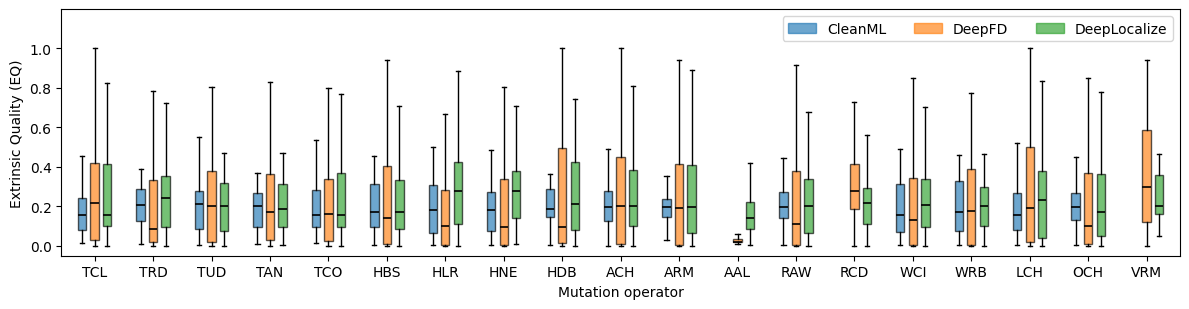

In [20]:
# -----------------------------
# Plot: grouped operator × dataset boxplot
# -----------------------------
plt.figure(figsize=(max(12, len(op_order) * 0.6), 3.2))

bp = plt.boxplot(
    data,
    positions=positions,
    widths=box_width,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0),
)

for patch, c in zip(bp["boxes"], colors):
    if c is not None:
        patch.set_facecolor(c)
        patch.set_alpha(0.65)

plt.xticks(tick_positions, tick_labels, rotation=0, ha="center")
plt.ylabel("Extrinsic Quality (EQ)")
plt.xlabel("Mutation operator")

# ---- Y-axis: ticks 0..1 step 0.2 + ±5% padding ----
ax = plt.gca()
ax.set_yticks(np.arange(0, 1.01, 0.2))  # 0, 0.2, ..., 1.0
pad = 0.2  # 5% of the [0,1] range
ax.set_ylim(-pad+0.15, 1 + pad)              # (-0.05, 1.05)

# Legend
handles = [
    mpatches.Patch(color=ds_to_color["CleanML"], alpha=0.65, label="CleanML"),
    mpatches.Patch(color=ds_to_color["DeepFD"], alpha=0.65, label="DeepFD"),
    mpatches.Patch(color=ds_to_color["DeepLocalize"], alpha=0.65, label="DeepLocalize"),
]
plt.legend(handles=handles, loc="upper right", ncol=3, frameon=True)

plt.tight_layout()

out_pdf = FIGURES_DIR / "operator_eq_boxplot_by_dataset.pdf"
plt.savefig(out_pdf, format="pdf")
print("Saved:", out_pdf.resolve())

plt.show()

## Notes
- Each box contains **all mutants** for a given (operator, dataset), pooled across all bugs in that dataset.
- If an operator is absent in a dataset, that box will be empty!

# Visualization (Quadrant-based IQ–EQ relationship analysis) — RQ3

This notebook implements a **quadrant-based analysis** to study the relationship between **Intrinsic Quality (IQ)** and
**Extrinsic Quality (EQ)** at the **mutant level**.

- **Input:** `results/quality/quality_<bug>_pre_training.csv`
- **Output (PDFs):**
  - `figures/rq3_quadrant_scatter_by_dataset.pdf` (scatter with quadrant lines)
  - `figures/rq3_quadrant_proportions_by_dataset.pdf` (proportions per quadrant)

## Idea
We define thresholds for "high" vs "low" on each axis and split the (IQ, EQ) plane into four regions:

- **High IQ, High EQ** (ideal)
- **High IQ, Low EQ** (resistant but unrealistic)
- **Low IQ, High EQ** (easy but realistic)
- **Low IQ, Low EQ** (low quality)

By default, thresholds are **dataset-specific medians** (robust, parameter-free).


In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
# -----------------------------
# Paths (edit if needed)
# -----------------------------
RESULTS_DIR = Path("results")
QUALITY_DIR = RESULTS_DIR / "quality"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("QUALITY_DIR:", QUALITY_DIR.resolve())
print("FIGURES_DIR:", FIGURES_DIR.resolve())

QUALITY_DIR: D:\Experiments\dl-mutant-quality\results\quality
FIGURES_DIR: D:\Experiments\dl-mutant-quality\figures


In [23]:
# -----------------------------
# Load mutant-level rows (selection datasets only)
# -----------------------------
def dataset_of_bug(bug_id: str) -> str:
    if bug_id.startswith("cleanml"):
        return "CleanML"
    if bug_id.startswith("deepfd"):
        return "DeepFD"
    if bug_id.startswith("deeplocalize"):
        return "DeepLocalize"
    return "Other"

csv_files = sorted(QUALITY_DIR.glob("quality_*_pre_training.csv"))
if not csv_files:
    raise FileNotFoundError(f"No quality CSVs found under {QUALITY_DIR}")

rows = []
skipped = 0
for f in csv_files:
    df = pd.read_csv(f)
    required = {"bug_id", "IQ", "EQ"}
    if not required.issubset(df.columns):
        skipped += 1
        continue

    bug_id = str(df["bug_id"].iloc[0])
    ds = dataset_of_bug(bug_id)
    if ds == "Other":
        continue  # exclude defect4ml for selection-dataset RQ3

    tmp = df[["IQ", "EQ"]].dropna().copy()
    tmp["IQ"] = tmp["IQ"].astype(float)
    tmp["EQ"] = tmp["EQ"].astype(float)
    tmp["dataset"] = ds
    rows.append(tmp)

pts = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

print("Skipped files:", skipped)
print("Loaded mutants:", len(pts))
print("Mutants per dataset:")
print(pts.groupby("dataset").size())

Skipped files: 0
Loaded mutants: 9612
Mutants per dataset:
dataset
CleanML         2748
DeepFD          3867
DeepLocalize    2997
dtype: int64


In [24]:
# -----------------------------
# Threshold mode
# -----------------------------
# Options:
# - "dataset_median": separate thresholds per dataset (default)
# - "global_median" : single threshold across all datasets
THRESHOLD_MODE = "dataset_median"

def compute_thresholds(df: pd.DataFrame, mode: str):
    if mode == "global_median":
        return float(df["IQ"].median()), float(df["EQ"].median())
    if mode == "dataset_median":
        out = {}
        for ds, sub in df.groupby("dataset"):
            out[ds] = (float(sub["IQ"].median()), float(sub["EQ"].median()))
        return out
    raise ValueError(f"Unknown THRESHOLD_MODE: {mode}")

th = compute_thresholds(pts, THRESHOLD_MODE)
print("Thresholds:", th)

Thresholds: {'CleanML': (0.7108657333340266, 0.1826693165176054), 'DeepFD': (0.6538111623806655, 0.1692307692307692), 'DeepLocalize': (0.6374927467108191, 0.2033602736510279)}


In [25]:
# -----------------------------
# Assign quadrants
# -----------------------------
def assign_quadrant(iq: float, eq: float, iq_thr: float, eq_thr: float) -> str:
    hi_iq = iq >= iq_thr
    hi_eq = eq >= eq_thr
    if hi_iq and hi_eq:
        return "High IQ, High EQ"
    if hi_iq and (not hi_eq):
        return "High IQ, Low EQ"
    if (not hi_iq) and hi_eq:
        return "Low IQ, High EQ"
    return "Low IQ, Low EQ"

pts_q = pts.copy()

if THRESHOLD_MODE == "global_median":
    iq_thr, eq_thr = th
    pts_q["quadrant"] = [assign_quadrant(iq, eq, iq_thr, eq_thr) for iq, eq in zip(pts_q["IQ"], pts_q["EQ"])]
else:
    q_series = []
    for ds, sub in pts_q.groupby("dataset"):
        iq_thr, eq_thr = th[ds]
        q_vals = [assign_quadrant(iq, eq, iq_thr, eq_thr) for iq, eq in zip(sub["IQ"], sub["EQ"])]
        q_series.append(pd.Series(q_vals, index=sub.index))
    pts_q["quadrant"] = pd.concat(q_series).sort_index()

print(pts_q["quadrant"].value_counts())

quadrant
Low IQ, High EQ     2663
High IQ, Low EQ     2662
High IQ, High EQ    2145
Low IQ, Low EQ      2142
Name: count, dtype: int64


Saved: D:\Experiments\dl-mutant-quality\figures\quadrant_scatter_by_dataset.pdf


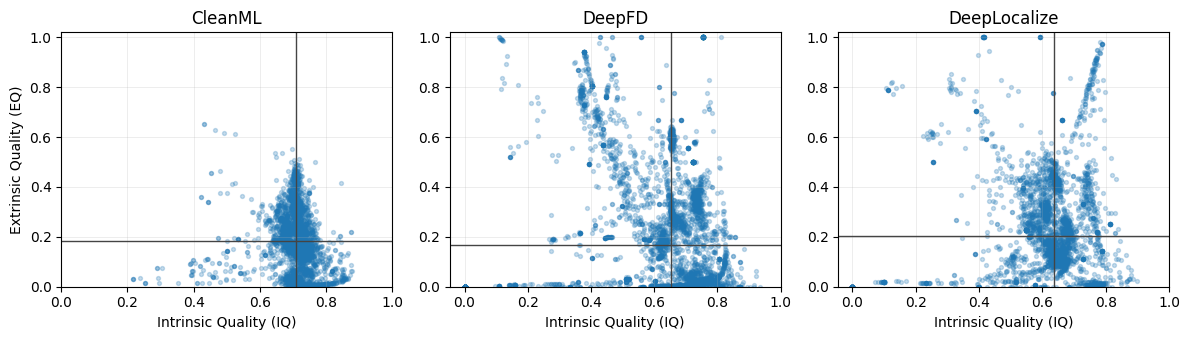

In [26]:
# -----------------------------
# Scatter plot with quadrant lines (3 panels, one per dataset)
# -----------------------------
datasets = ["CleanML", "DeepFD", "DeepLocalize"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, ds in zip(axes, datasets):
    sub = pts_q[pts_q["dataset"] == ds].copy()
    if sub.empty:
        ax.set_title(ds + " (no data)")
        ax.set_xlabel("Intrinsic Quality (IQ)")
        ax.set_ylabel("Extrinsic Quality (EQ)")
        ax.grid(True, linewidth=0.4, alpha=0.4)
        
        ticks = np.linspace(0, 1, 6)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        continue

    if THRESHOLD_MODE == "global_median":
        iq_thr, eq_thr = th
    else:
        iq_thr, eq_thr = th[ds]

    ax.scatter(sub["IQ"], sub["EQ"], s=8, alpha=0.25)
    
    quad_color = "#444444"   # dark gray 
    ax.axvline(iq_thr, linewidth=1.0, color=quad_color)
    ax.axhline(eq_thr, linewidth=1.0, color=quad_color)

    ax.set_title(ds)
    ax.set_xlabel("Intrinsic Quality (IQ)")
    ax.grid(True, linewidth=0.4, alpha=0.4)
      
    ticks = np.linspace(0, 1, 6)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_ylim(0, 1.02)           # add 0.02 headroom

axes[0].set_ylabel("Extrinsic Quality (EQ)")

#fig.suptitle("IQ–EQ relationship via quadrant split (thresholds = medians)", y=0.95)
fig.tight_layout()

out1 = FIGURES_DIR / "quadrant_scatter_by_dataset.pdf"
fig.savefig(out1, format="pdf", bbox_inches="tight")
print("Saved:", out1.resolve())

plt.show()

# Visualization (Validation on defect4ML) — RQ4

This notebook generates:

- **Figure 1**: Mutants kept bar chart. Number of mutants before and after selection
- **Figure 2**: Relative ratios after/before (unitless) for High–High, median IQ, median EQ

Input:
- `results/selection/defect4ml_validation_summary.csv`

Outputs (PDF) saved to `figures/`.


In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

CSV_PATH = os.path.join('results', 'selection', 'defect4ml_validation_summary.csv')
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f'Expected file not found: {CSV_PATH}.\n'
        'Run validate_selection_on_defect4ml.py first.'
    )

df = pd.read_csv(CSV_PATH).sort_values('hit_rate_threshold').reset_index(drop=True)

required = {
    'hit_rate_threshold', 'selected_families',
    'defect4ml_mutants_before', 'defect4ml_mutants_after',
    'defect4ml_reduction_ratio',
    'defect4ml_median_IQ_before', 'defect4ml_median_IQ_after',
    'defect4ml_median_EQ_before', 'defect4ml_median_EQ_after',
    'defect4ml_high_high_prop_before', 'defect4ml_high_high_prop_after',
}
missing = required - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df['thr_label'] = df['hit_rate_threshold'].apply(lambda v: f"{int(round(float(v)*100))}%")
baseline_n = int(df.loc[0, 'defect4ml_mutants_before'])
baseline_hh = float(df.loc[0, 'defect4ml_high_high_prop_before'])
baseline_iq = float(df.loc[0, 'defect4ml_median_IQ_before'])
baseline_eq = float(df.loc[0, 'defect4ml_median_EQ_before'])

df

,hit_rate_threshold,selected_families,defect4ml_mutants_before,defect4ml_mutants_after,defect4ml_reduction_ratio,defect4ml_median_IQ_before,defect4ml_median_IQ_after,defect4ml_median_EQ_before,defect4ml_median_EQ_after,defect4ml_high_high_prop_before,defect4ml_high_high_prop_after,thr_label
0,0.20,67,4939,3095,0.373355,0.67028,0.674064,0.252387,0.251954,0.221097,0.249758,20%
1,0.25,51,4939,2194,0.555781,0.67028,0.675613,0.252387,0.257783,0.221097,0.265725,25%
2,0.30,27,4939,721,0.854019,0.67028,0.677446,0.252387,0.258065,0.221097,0.262136,30%


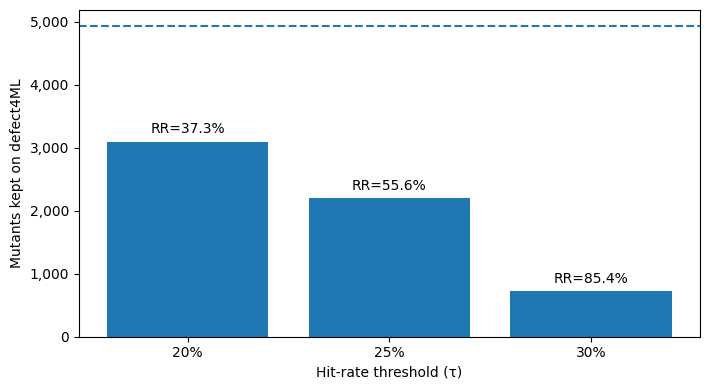

Saved: figures\mutants_kept_by_threshold.pdf


In [28]:
# Figure 1: Mutants kept (after selection) per threshold

x = list(range(len(df)))
labels = df['thr_label'].tolist()
kept = df['defect4ml_mutants_after'].astype(int).tolist()
rr = df['defect4ml_reduction_ratio'].astype(float).tolist()

plt.figure(figsize=(7.2, 4.0))
plt.bar(x, kept)
plt.axhline(baseline_n, linestyle='--')

plt.xticks(x, labels)
plt.xlabel('Hit-rate threshold (τ)')
plt.ylabel('Mutants kept on defect4ML')

for xi, yi, r in zip(x, kept, rr):
    plt.annotate(f"RR={r*100:.1f}%", (xi, yi), textcoords='offset points', xytext=(0, 6), ha='center')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(v):,}"))
plt.tight_layout()

out_pdf = os.path.join(FIG_DIR, 'mutants_kept_by_threshold.pdf')
plt.savefig(out_pdf)
plt.show()
print('Saved:', out_pdf)

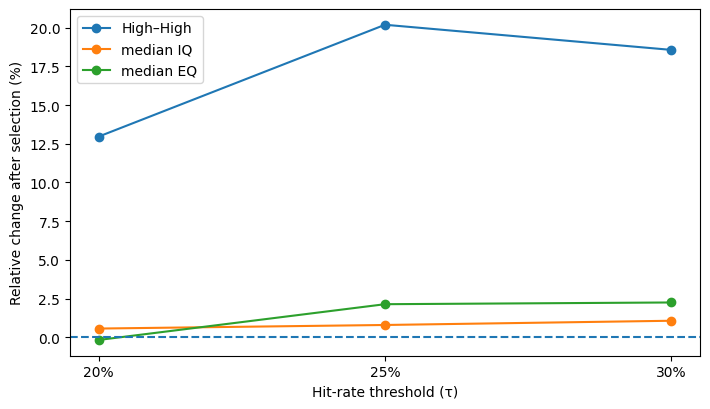

Saved: figures\relative_change_percent.pdf


In [29]:
# Figure 2: relative ratios after/before shown as % change
# (ratio - 1) × 100 so all three are in the same unit (% change)

x = list(range(len(df)))
labels = df['thr_label'].tolist()

ratio_hh_pct = (df['defect4ml_high_high_prop_after'] / df['defect4ml_high_high_prop_before'] - 1.0) * 100.0
ratio_iq_pct = (df['defect4ml_median_IQ_after'] / df['defect4ml_median_IQ_before'] - 1.0) * 100.0
ratio_eq_pct = (df['defect4ml_median_EQ_after'] / df['defect4ml_median_EQ_before'] - 1.0) * 100.0

plt.figure(figsize=(7.2, 4.2))
plt.plot(x, ratio_hh_pct, marker='o', label='High–High')
plt.plot(x, ratio_iq_pct, marker='o', label='median IQ')
plt.plot(x, ratio_eq_pct, marker='o', label='median EQ')
plt.axhline(0.0, linestyle='--')

#for xi, v in zip(x, ratio_hh_pct):
 #   plt.annotate(f"{v:+.1f}%", (xi, v), textcoords='offset points', xytext=(0, 6), ha='center')

plt.xticks(x, labels)
plt.xlabel('Hit-rate threshold (τ)')
plt.ylabel('Relative change after selection (%)')
plt.legend()
plt.tight_layout()

out_c = os.path.join(FIG_DIR, 'relative_change_percent.pdf')
plt.savefig(out_c)
plt.show()
print('Saved:', out_c)